# DAS next to seismological stations

The cable in these tutorials runs along the coast of the Coquimbo region, in
central Chile — one of the best-instrumented subduction margins in the
world. So for every earthquake the fiber records, there are permanent
seismometers that recorded it too.

Xdas reads both. This notebook puts a DAS acquisition and a regional network
into the same objects, and runs the *same* picking call on both.

In [ ]:
from pathlib import Path

import numpy as np
import obspy
import pandas as pd
from obspy import UTCDateTime

import xdas as xd

T0 = UTCDateTime("2023-11-03T12:25:30")
T1 = UTCDateTime("2023-11-03T12:28:30")

## Opening the stations

The waveforms were fetched from EarthScope once, by `install.py`, and written
as one miniSEED file per station in `data/stations/` — next to the
`stations.xml` inventory that says where those stations are. Nothing below
touches the network.

In [ ]:
stream = obspy.Stream()
for path in sorted(Path("data/stations").glob("*.mseed")):
    stream += obspy.read(str(path))

stream.trim(T0, T1)
stream = obspy.Stream([tr for tr in stream if tr.stats.npts > 1000])
print(f"{len({(tr.stats.network, tr.stats.station) for tr in stream})} stations")

## One thing to fix before Xdas sees it

The three components of a station are not always timestamped on exactly the
same grid — here they differ by anything from a microsecond to a few
milliseconds. That is harmless for most purposes, but it stops them from
being assembled into one array, so we snap each start time onto its own
sampling grid first:

In [3]:
print("offsets before:", sorted({round(tr.stats.starttime.timestamp % 0.01, 7) for tr in stream})[:4])

for trace in stream:
    delta = trace.stats.delta
    trace.stats.starttime = UTCDateTime(
        round(trace.stats.starttime.timestamp / delta) * delta
    )

stream.write("outputs/stations.mseed", format="MSEED")

offsets before: [0.009998, 0.01]


## Opening it with Xdas

Nothing changes at the call site: the format is recognized from the file, and
miniSEED is decoded through ObsPy, as are SAC, GSE2 and everything else it
handles. Each contiguous trace becomes one lazy `DataArray`, and the
collection mirrors the `Stream` — nested network, station, location, channel.

In [4]:
dc = xd.open("outputs/stations.mseed")
dc

Network:
  C1: 
    Station:
      CO01: 
        Location:
          --: 
            Channel:
              HHE: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
              HHN: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
              HHZ: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
      CO02: 
        Location:
          --: 
            Channel:
              HHE: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
              HHN: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
              HHZ: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
      CO03: 
        Location:
          --: 
            Channel:
              HHE: 
                Acquisition:
                  0: <xdas.DataArray (time: 18001)>
              HHN: 
                Acquisition:
              

`stack` collapses a level of that tree into an array dimension. Here the
three channels of each station become one `(channel, time)` array:

In [5]:
dc = xd.stack(dc, "channel", join="inner")
dc

Network:
  C1: 
    Station:
      CO01: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18001)>
      CO02: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18001)>
      CO03: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18001)>
      CO04: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18000)>
      CO05: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18001)>
      VA03: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18001)>
      VA06: 
        Location:
          --: 
            Acquisition:
              0: <xdas.DataArray (channel: 3, time: 18000)>

```{note}
`join="inner"` is doing real work: the components of a station often differ
by a sample in length, and the inner join trims them to what they share.
```

One station, drawn:

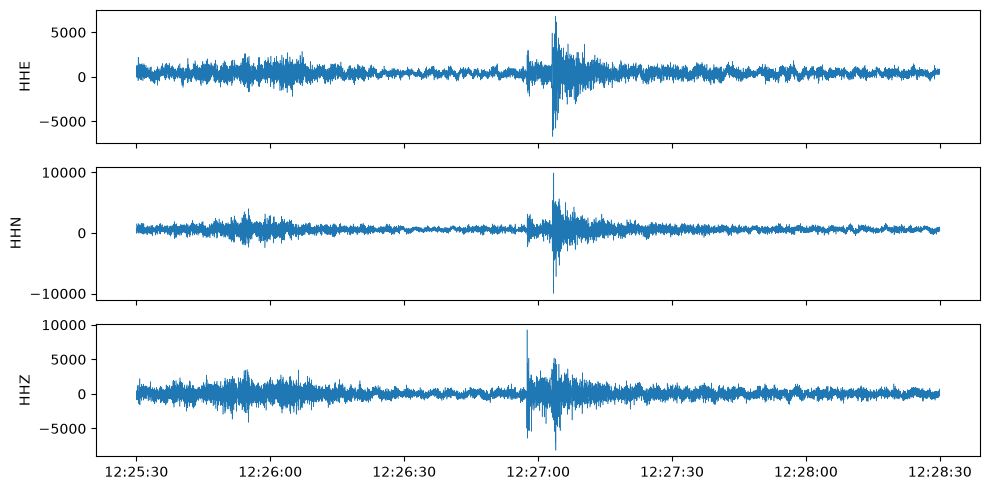

In [6]:
import matplotlib.pyplot as plt

station = dc["C1"]["CO05"]["--"][0]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 5))
for ax, component in zip(axes, station["channel"].values):
    trace = station.sel(channel=component)
    ax.plot(trace["time"].values, trace.values, lw=0.4)
    ax.set_ylabel(str(component))
plt.tight_layout()
plt.show()

## The same picker, on a different instrument

This is the point of the notebook. The call below is character for character
the one used on the DAS acquisition — the same model, the same thresholds:

In [7]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")
picks = xd.pick(dc, model, thresh={"P": 0.3, "S": 0.3}, device="cpu")
picks.sort_values("time")

,network,station,location,trace,phase,time,value
8,C1,CO05,--,0,P,2023-11-03 12:26:57.420,0.967788
10,C1,VA06,--,0,S,2023-11-03 12:26:59.140,0.327359
9,C1,CO05,--,0,S,2023-11-03 12:27:03.020,0.860738
4,C1,CO03,--,0,P,2023-11-03 12:27:11.700,0.911087
0,C1,CO01,--,0,P,2023-11-03 12:27:14.100,0.698469
2,C1,CO02,--,0,P,2023-11-03 12:27:14.500,0.715876
6,C1,CO04,--,0,P,2023-11-03 12:27:27.130,0.482439
5,C1,CO03,--,0,S,2023-11-03 12:27:27.840,0.536183
11,C1,VA06,--,0,S,2023-11-03 12:27:29.940,0.399504
1,C1,CO01,--,0,S,2023-11-03 12:27:30.820,0.780952


The pick table comes back flat, with each row labelled by where in the tree
it came from — network, station, location — so it merges directly with a
DAS pick table.

## What the cable saw and the network did not

Now compare with the DAS picks from notebook 03:

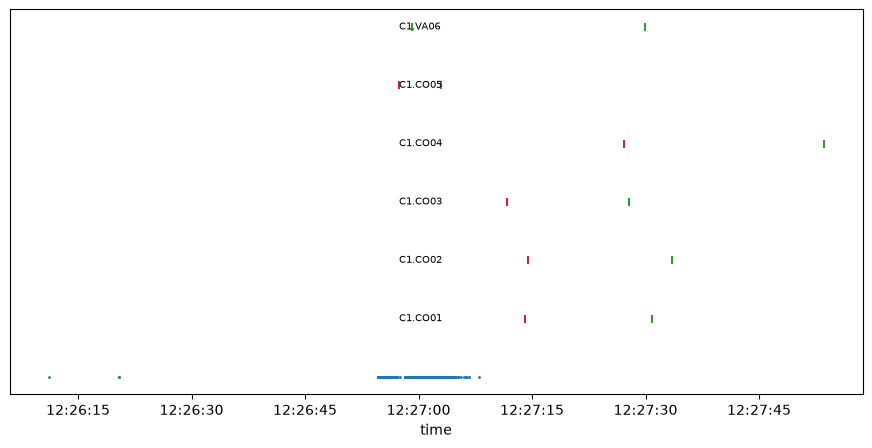

In [8]:
das = pd.read_csv("outputs/picks.csv", parse_dates=["time"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(das["time"], np.zeros(len(das)), s=1, c="C0", label="DAS channels")
for i, (name, group) in enumerate(picks.groupby(["network", "station"]), start=1):
    for phase, colour in [("P", "C3"), ("S", "C2")]:
        sub = group[group["phase"] == phase]
        ax.scatter(sub["time"], np.full(len(sub), i), s=40, c=colour, marker="|")
    ax.text(picks["time"].min(), i, ".".join(name), fontsize=7, va="center")
ax.set_yticks([])
ax.set_xlabel("time")
plt.show()

It is tempting to read that figure as two earthquakes — one at 12:26:55 on
the cable and at `CO05`, another at 12:27:12 on everything else. It is one.
What separates them is distance: this is ordinary travel-time moveout across
a network 250 km across, and the next notebook checks it arrival by arrival.

The ordering is the interesting part. The fiber picks it up first, before
any land station, because it is the closest instrument to the source — and
it contributes not one arrival but thousands.

Two land stations carry almost all the information here, which is thin for
locating anything. That is the problem the next notebook runs into.

In [9]:
picks.to_csv("outputs/station_picks.csv", index=False)